# 画像の Signal-to-Noise Ratio (SNR) — 視覚的デモ

**SNR（信号対雑音比）** の概念は 1 次元信号だけでなく、**2 次元画像**にもそのまま適用できます。

## 定義

$$\text{SNR}_{\text{dB}} = 10 \cdot \log_{10}\left(\frac{P_{\text{signal}}}{P_{\text{noise}}}\right)$$

ここで電力は全画素の平均二乗値：

$$P = \frac{1}{HW}\sum_{i,j} x_{i,j}^2$$

## このノートブックの内容

1. グレースケール参照画像を読み込む（skimage がなければ合成画像を生成）  
2. 制御された SNR レベル（30, 20, 10, 0 dB）でガウスノイズを付加する  
3. **空間領域**と**周波数領域（2D FFT）** の両方で効果を可視化する  
4. 測定 SNR が目標値と ±0.1 dB 以内で一致することを検証する  
5. *（オプション）* スライダーで任意の SNR を対話的に探索する

> **1 次元信号版** は `SNR.ipynb` を参照してください。ノイズ付加の数式・SNR 検証ロジックは共通です。

---
## 1 — セットアップ

In [22]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

SNR_LEVELS = [30, 20, 10, 0]  # dB
RNG        = np.random.default_rng(42)

---
## 2 — 画像の読み込み

`skimage` がインストールされていれば標準テスト画像 **camera**（512×512 グレースケール）を使います。  
未インストールの場合は NumPy だけで生成した合成画像にフォールバックします。  

画素値は **[0, 1]** に正規化します（電力計算をスケール不変にするため）。

Image: Camera (skimage)  size: 512x512  range: [0.000, 1.000]


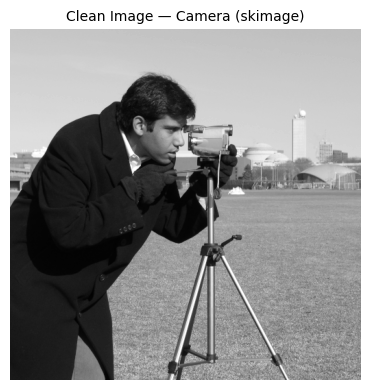

In [23]:
try:
    from skimage import data as skdata
    image      = skdata.camera().astype(np.float64) / 255.0
    image_name = 'Camera (skimage)'
except ImportError:
    # synthetic image: low-freq gradient + high-freq stripes
    s   = 256
    x   = np.linspace(0, 1, s)
    xx, yy = np.meshgrid(x, x)
    image  = 0.5 + 0.3 * np.sin(2 * np.pi * 4 * xx) * np.cos(2 * np.pi * 4 * yy) \
                 + 0.2 * np.sin(2 * np.pi * 12 * xx + 1.0)
    image  = np.clip(image, 0, 1)
    image_name = 'Synthetic Image (NumPy)'

H, W = image.shape
print(f'Image: {image_name}  size: {H}x{W}  range: [{image.min():.3f}, {image.max():.3f}]')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'Clean Image — {image_name}', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 3 — ノイズの付加

### 目標 SNR からノイズ標準偏差を導出する

1 次元版とまったく同じ式を使います：

$$P_n = \frac{P_s}{10^{\,\text{SNR}_{\text{dB}}/10}}, \qquad \sigma = \sqrt{P_n}$$

`add_noise` は配列形状を問わず動作するため、1D・2D どちらにも適用できます。  
ノイズを加えた後は **[0, 1] にクリップ**して画素値の範囲を保ちます。  

> **注意**: クリッピングは画素値が端付近の場合にノイズを非線形に歪めます。  
> SNR が高い（30 dB 程度）うちは影響がほぼ無視できますが、低 SNR（0 dB）では  
> 残差法の測定値と目標値が数 dB 乖離することがあります（次セクション参照）。

In [24]:
def add_noise(image, snr_db, rng):
    """Return (noisy_image, noise) with the given SNR in dB."""
    p_signal = np.mean(image**2)
    p_noise  = p_signal / (10 ** (snr_db / 10))
    sigma    = np.sqrt(p_noise)
    noise    = rng.normal(0, sigma, size=image.shape)
    return np.clip(image + noise, 0, 1), noise


noisy_images = {}
noises       = {}
for snr in SNR_LEVELS:
    noisy_images[snr], noises[snr] = add_noise(image, snr, RNG)

print('Noise sigma per level:')
for snr in SNR_LEVELS:
    sigma = np.std(noises[snr])
    print(f'  SNR {snr:3d} dB  ->  sigma_noise = {sigma:.4f}')

Noise sigma per level:
  SNR  30 dB  ->  sigma_noise = 0.0185
  SNR  20 dB  ->  sigma_noise = 0.0583
  SNR  10 dB  ->  sigma_noise = 0.1842
  SNR   0 dB  ->  sigma_noise = 0.5828


---
## 4 — 空間領域の比較

上段がクリーン画像、下の 4 枚が SNR 低下順のノイズ付加画像です。  
カラーマップ（灰色）は共通スケール [0, 1] で固定し、輝度変化がノイズのみに起因することを明確にしています。

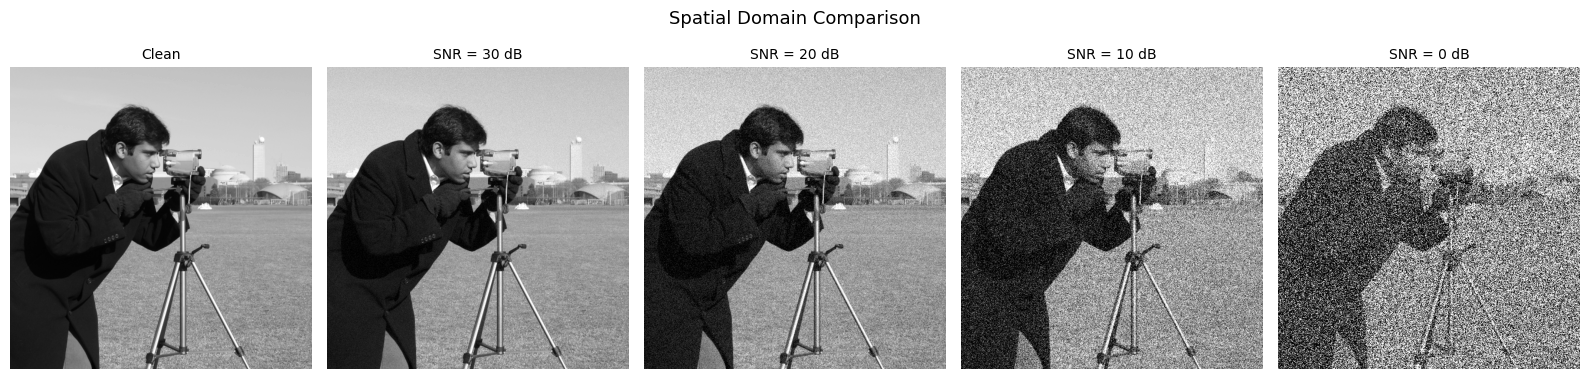

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

all_images = [('Clean', image)] + [(f'SNR = {snr} dB', noisy_images[snr]) for snr in SNR_LEVELS]

for ax, (title, img) in zip(axes, all_images):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('Spatial Domain Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 — 周波数領域（2D FFT）解析

2D FFT のログ振幅スペクトルを表示します。  

* **クリーン画像**: エッジや繰り返しパターンが特定周波数に集中したスパイクを形成する  
* **ノイズ付加後**: 白色雑音は全周波数に均等なフロアを追加する → SNR が下がるほどフロアが上昇して構造が埋もれる

スペクトルは DC 成分を中心に並び替えて表示します（`np.fft.fftshift`）。

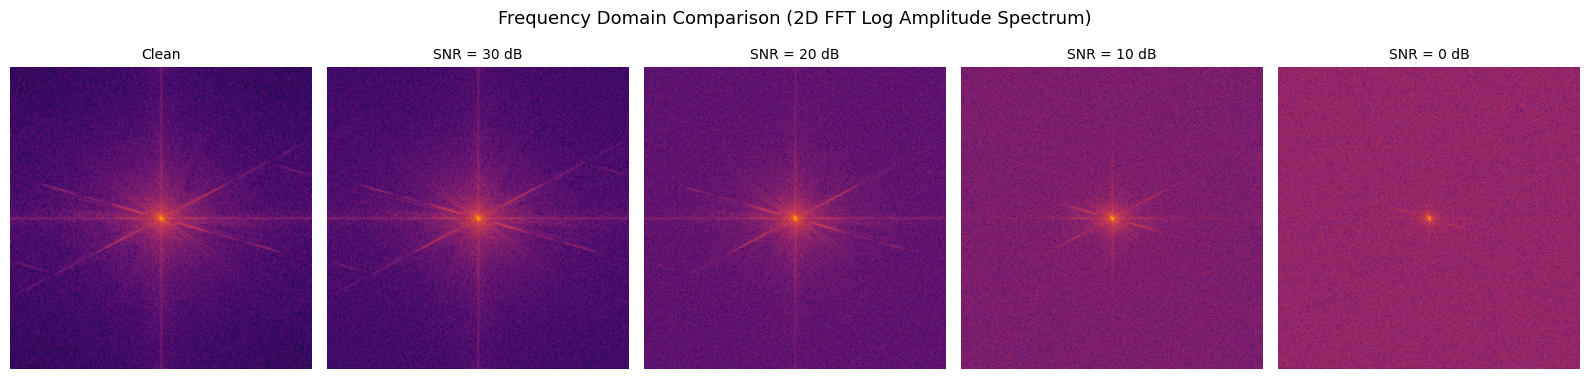

In [26]:
def compute_spectrum_2d(img):
    fft2  = np.fft.fftshift(np.fft.fft2(img))
    mag   = np.abs(fft2)
    return np.log1p(mag)  # log(1 + |F|) spreads dynamic range; dividing by H*W first would crush AC components to near-zero


fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (title, img) in zip(axes, all_images):
    spec = compute_spectrum_2d(img)
    im   = ax.imshow(spec, cmap='inferno')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('Frequency Domain Comparison (2D FFT Log Amplitude Spectrum)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 — SNR の検証

2 種類の測定方法で比較します：

* **方法 1 — 厳密法**: 保存したノイズ配列をそのまま使う  
  $\text{SNR} = 10 \log_{10}(P_s / P_n)$ — **クリッピング前の σ** から計算するため目標値に正確に一致する

* **方法 2 — 残差法**: ノイズ画像からクリーン画像を引いて推定する  
  $\hat{n} = x_{\text{noisy}} - x_{\text{clean}}$、次に $\text{SNR} = 10 \log_{10}(P_s / P_{\hat{n}})$  
  `noisy` はクリップ済みのため、$\hat{n}$ はクリップで削られた成分を含まず**実効ノイズが過小評価**される。  
  → 高 SNR（30, 20 dB）ではずれが小さく、低 SNR（0 dB）では数 dB の乖離が生じる（画像特有の現象）。

In [27]:
p_signal = np.mean(image**2)

print(f"{'Target dB':>10}  {'Measured (exact)':>18}  {'Measured (residual)':>20}")
print('-' * 54)

for snr in SNR_LEVELS:
    p_noise_exact  = np.mean(noises[snr]**2)
    measured_exact = 10 * np.log10(p_signal / p_noise_exact)

    residual      = noisy_images[snr] - image
    p_noise_res   = np.mean(residual**2)
    measured_res  = 10 * np.log10(p_signal / p_noise_res)

    print(f"{snr:>10}  {measured_exact:>17.4f}  {measured_res:>19.4f}")

 Target dB    Measured (exact)   Measured (residual)
------------------------------------------------------
        30            29.9891              30.0332
        20            19.9991              20.1937
        10            10.0019              10.9770
         0            -0.0012               3.8004


---
## 7 — まとめ

* **SNR は画像の明瞭さを定量化する**: SNR が高いほど信号が支配的、低いほどノイズが支配的。
* **30 dB** — ノイズはほぼ見えず、クリーン画像と区別がつかない。
* **20 dB** — 粒状感が出始めるが、エッジや構造は明確に残る。
* **10 dB** — ディテールが失われ始め、ノイズが画像全体を覆う。
* **0 dB** — 信号電力とノイズ電力が等しく、元の画像はほぼ判別不能。
* **2D FFT** は診断ツールとして有効：空間領域で判別困難になってもスペクトル構造の変化が残る。
* ノイズ付加の数式は 1D・2D で共通。`SNR.ipynb`（1 次元信号版）と同一の `add_noise` 実装を使用。

---
## 8 — オプション：インタラクティブスライダー

`ipywidgets` が必要です。  
インストール: `pip install ipywidgets`（クラシック Notebook の場合は追加で `jupyter nbextension enable --py widgetsnbextension`）

In [28]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    def plot_snr_image(snr_db=20):
        noisy, _ = add_noise(image, snr_db, np.random.default_rng(snr_db))
        diff     = np.abs(noisy - image)

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))

        axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title('Clean', fontsize=10)

        axes[1].imshow(noisy, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title(f'Noisy ({snr_db} dB)', fontsize=10)

        im = axes[2].imshow(diff, cmap='hot', vmin=0, vmax=diff.max())
        axes[2].set_title('Difference |noisy - clean|', fontsize=10)
        plt.colorbar(im, ax=axes[2], fraction=0.046)

        for ax in axes:
            ax.axis('off')

        p_s = np.mean(image**2)
        p_n = np.mean((noisy - image)**2)
        fig.suptitle(f'SNR target: {snr_db} dB  /  measured: {10*np.log10(p_s/p_n):.2f} dB', fontsize=11)
        plt.tight_layout()
        plt.show()

    interact(plot_snr_image,
             snr_db=widgets.IntSlider(min=0, max=40, step=1, value=20,
                                      description='SNR (dB)',
                                      continuous_update=False))

except ImportError:
    print('ipywidgets is not installed — skipping interactive slider.')
    print('Install with:  pip install ipywidgets')

interactive(children=(IntSlider(value=20, continuous_update=False, description='SNR (dB)', max=40), Output()),…